# ppg-cfpwv-resnet: executed walkthrough

These outputs were generated by actually running the cells on artificial waveforms. They are software checks, not the study dataset or reproduced paper results.

Install `requirements-notebook.txt` and select that environment as the notebook kernel. The demo uses one epoch and no pretrained downloads. For a rerun, choose a new `RUN` folder or intentionally remove the old demo folder.

Install notebook dependencies with `python -m pip install -r requirements-notebook.txt`.

In [1]:
from pathlib import Path
import json, subprocess, sys
import pandas as pd
ROOT=Path.cwd()
if not (ROOT/'train.py').exists(): ROOT=ROOT.parent
assert (ROOT/'train.py').exists(), 'Open this notebook inside its repository.'
RUN=ROOT/'runs'/'notebook-demo'
print('Artificial-data software check: not PWDB or clinical results.')

Artificial-data software check: not PWDB or clinical results.


In [2]:
command=[sys.executable,str(ROOT/'train.py'),'--demo','--output',str(RUN),'--models']+['resnet18']
result=subprocess.run(command,cwd=ROOT,capture_output=True,text=True)
print(result.stdout)
if result.returncode: raise RuntimeError(result.stderr)

resnet18: fold 1/1
Epoch 1: train=0.94060, validation=1.64218
Completed: /workspace/scratch/9793ff8eed97/output/research-portfolio/ppg-cfpwv-resnet/runs/notebook-demo



In [3]:
record=json.loads((RUN/'run.json').read_text())
print('Status:',record['status'])
print('Paper reproduction verified:',record['paper_reproduction_verified'])
summary=json.loads((RUN/'summary.json').read_text())
for name,values in summary['models'].items():
    metric='accuracy' if 'accuracy' in values else 'rmse_m_s'
    print(name,metric,values[metric])
print('One-epoch fixture scores are not research performance claims.')

Status: artificial_data_software_check
Paper reproduction verified: False
resnet18 rmse_m_s {'mean': 1.2725958805984454, 'std': 0.0}
One-epoch fixture scores are not research performance claims.


In [4]:
command=[sys.executable,str(ROOT/'predict.py'),'--model-dir',str(RUN/'resnet18'/'fold_1'),
         '--signals',str(RUN/'demo_input'/'signals.csv'),'--output',str(RUN/'inference_example.csv')]
result=subprocess.run(command,cwd=ROOT,capture_output=True,text=True)
print(result.stdout)
if result.returncode: raise RuntimeError(result.stderr)
print(pd.read_csv(RUN/'inference_example.csv').head().to_string(index=False))

Saved 72 predictions.

subject_id  predicted_cfpwv_m_s                   model_status
 demo-0000             7.920253 artificial_data_software_check
 demo-0001             7.721510 artificial_data_software_check
 demo-0002             7.334364 artificial_data_software_check
 demo-0003             6.942263 artificial_data_software_check
 demo-0004             6.957490 artificial_data_software_check


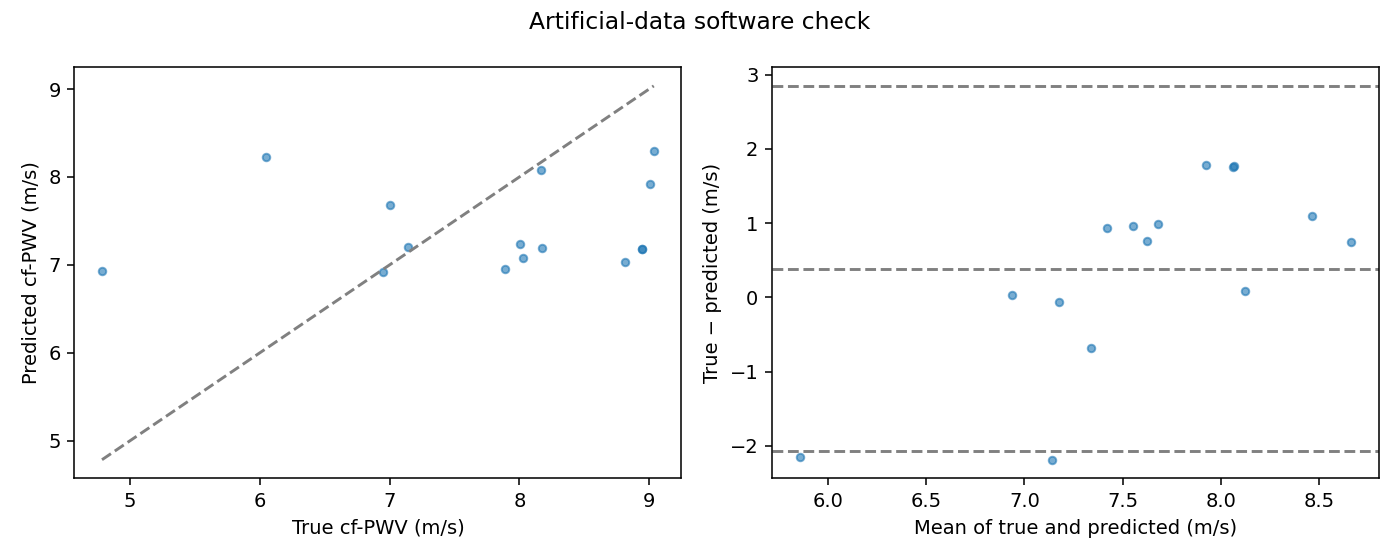

In [5]:
from IPython.display import Image, display
display(Image(filename=str(RUN/'resnet18'/'evaluation.png')))

## Research runs

Follow README.md to verify and convert your original CSV exports. Omit `--demo`, set the correct artery and signal settings, and retain the generated configuration and splits with any reported results.